# Machine Learning for Single-Cell Biology
***

Winter Semester 2025/26<br />
Manfred Claassen, Maximilian Wirth, Jan Schleicher
<br />
***

## Assignment 3

In [25]:
import numpy as np
import pandas as pd
import umap
from scipy import stats
from statsmodels.stats.multitest import multipletests
from sklearn.decomposition import FactorAnalysis
import os
from matplotlib import pyplot as plt
import seaborn as sns
import gseapy as gp
from gseapy import barplot

from typing import List, Union, Tuple

sns.set_style("ticks")
%matplotlib inline

In [26]:
DATA_PATH = "data/"
OUTPUT_PATH = "output/"
os.makedirs(OUTPUT_PATH, exist_ok=True)

### Task 1

In [27]:
def task1a_get_mean_per_cell_type(expression_df: pd.DataFrame,
                                  cell_type_df: pd.DataFrame,
                                  gene_list: List[str],
                                  cell_type_col: str = "cell_type") -> pd.DataFrame:
    """
    Compute the mean expression per cell type from a single-cell expression matrix.
    :param expression_df: A DataFrame of shape (n_cells, n_genes) containing the expression data.
    :param cell_type_df: A DataFrame of shape (n_cells, n_annotations) containing metadata (including cell type).
    :param gene_list: A list of marker genes for which to compute mean expression.
    :param cell_type_col: The name of the column in cell_type_df that contains cell type annotations.
    :return: A DataFrame of shape (n_cell_types, n_markers) with the mean expression per cell type for the given genes.
    """
    cell_type_means = pd.DataFrame(index=cell_type_df[cell_type_col].astype("category").cat.categories,
                                   columns=gene_list,
                                   dtype=float)
    #########################
    # filter for cell_types and compute for each the mean gene_expression -> collect into cell_type_means dataframe
    for cell_type in cell_type_df["cell_type"].astype("category").cat.categories: 
        for gene in gene_list:
           cell_type_means.loc[cell_type, gene] = np.mean(expression_df.loc[cell_type_df["cell_type"] == cell_type, gene])

    
    # expression_means = [np.mean(expression_df[gene]) for gene in gene_list]
    print(cell_type_means)
  
    #########################
    return cell_type_means

In [28]:
def task1a_plot_heatmap(cell_type_means: pd.DataFrame) -> None:
    """
    Plot a heatmap displaying mean expression per cell type.
    :param cell_type_means: A DataFrame of shape (n_cell_types, n_markers) with the mean expression per cell type.
    :return:
    """
    #########################

    plt.figure(figsize=(11,3))   
    plt.title("Heatmap of mean gene expression per cell type", fontsize=14) 
    plt.xlabel("Marker genes")
    plt.ylabel("Cell types")
    sns.heatmap(cell_type_means, annot=True, cmap="Reds", annot_kws={"size":8})
    plt.show()

    #########################
    return None

In [29]:
def task1c_compute_umap(expression_df: pd.DataFrame) -> np.ndarray:
    """
    Compute a UMAP embedding of the expression data.
    :param expression_df: A Dataframe of shape (n_cells, n_genes) containing the expression data.
    :return: An array of shape (n_cells, 2) containing the embedding coordinates.
    """
    embedding = np.zeros((expression_df.shape[0], 2))
    #########################
    umap_computation = umap.UMAP(random_state=42)
    embedding = umap_computation.fit_transform(expression_df)

    #########################
    return embedding

In [30]:
# Load data
expression_data = pd.read_csv(os.path.join(DATA_PATH, "expression_data_1.txt"), sep="\t", index_col=0)
cell_type_data = pd.read_csv(os.path.join(DATA_PATH, "cell_type_data_1.txt"), sep="\t", index_col=0)

        CCR7      CD14      IL7R    S100A4     MS4A1      CD8A    FCGR3A  \
B   0.450050  0.013957  0.087897  0.521108  1.944864  0.019383  0.010428   
MP  0.001695  1.488222  0.014098  3.201191  0.004345  0.003538  0.155906   
NK  0.086120  0.014691  0.714987  2.638310  0.024411  0.648337  0.917810   

       MS4A7      NKG7    FCER1A      PPBP  
B   0.024018  0.040478  0.000000  0.003125  
MP  0.225230  0.075358  0.001059  0.023283  
NK  0.001588  3.152994  0.001931  0.002862  


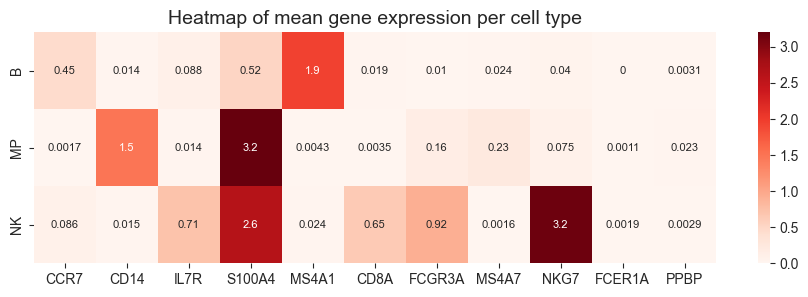

In [31]:
# Get mean expression of marker genes per cell type
marker_genes = ["CCR7", "CD14", "IL7R", "S100A4", "MS4A1", "CD8A", "FCGR3A", "MS4A7", "NKG7", "FCER1A", "PPBP"]
mean_expression = task1a_get_mean_per_cell_type(expression_df=expression_data,
                                                cell_type_df=cell_type_data,
                                                gene_list=marker_genes)


task1a_plot_heatmap(mean_expression)

**Provide your text answers for Task 1B here**

Since a marker gene will be used to identify the cell_type, these gene must be expressed higher with a certain cell type, while other genes have lower expression here.

**For cell type B:** we choose gene _MS4A1_ since this is most highly expressed here

**For cell type MP:** we choose gene _CD14_ and *not* _S100A4_, because even though _S100A4_ has higher expression, NK also shows higher expression for this gene.

**For cell type NK:** we choose gene _NK67_, since it hs the highest expression level and no other cell_type has high expression on this gene

=> These genes can now be used for identification

In [32]:
# Compute UMAP
umap_coords = task1c_compute_umap(expression_df=expression_data)

c:\Users\Anwender\Desktop\Uni_Tuebingen\Master\1. Semester\ML Single Cell\Assignments\Assignment03\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


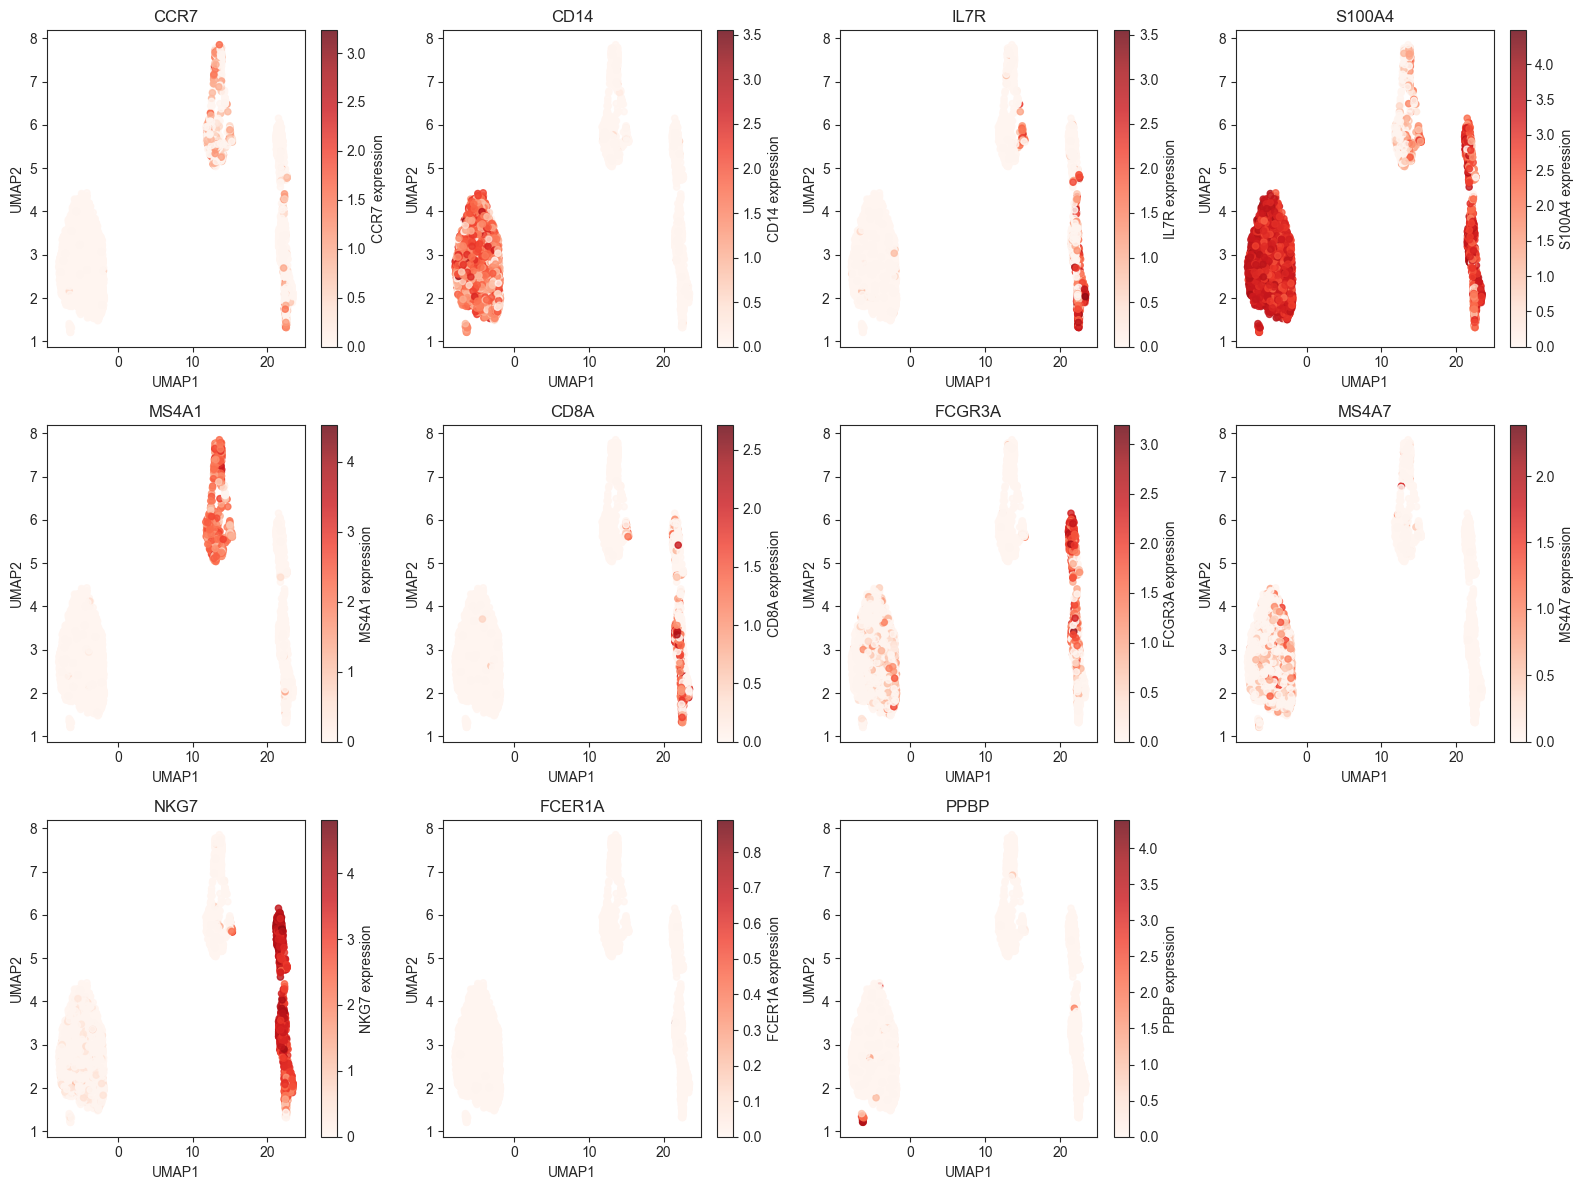

In [33]:
# Plot UMAPs with gene expression
#########################
# for gene in marker_genes:
#     plt.figure(figsize=(6,5))
#     plt.scatter(umap_coords[:,0], umap_coords[:,1], c=expression_data[gene], cmap="Reds", s=20, alpha=0.8)
#     plt.colorbar(label=f"{gene} expression")
#     plt.xlabel("UMAP1")
#     plt.ylabel("UMAP2")
#     plt.title(f"UMAP projection colored by {gene}")
#     plt.show()

n_markers = len(marker_genes)
n_cols = 4
n_rows = (n_markers + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 4*n_rows))
axes = axes.flatten()

for i, gene in enumerate(marker_genes):
    ax = axes[i]
    sc = ax.scatter(
        umap_coords[:,0], umap_coords[:,1],
        c=expression_data[gene],
        cmap="Reds",
        s=20,
        alpha=0.8
    )
    ax.set_title(gene)
    ax.set_xlabel("UMAP1")
    ax.set_ylabel("UMAP2")
    fig.colorbar(sc, ax=ax, label=f"{gene} expression")

# leere Subplots entfernen, falls n_markers < n_rows*n_cols
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

#########################

### Task 2

In [ ]:
def task2a_differential_expression_testing(expression_df: pd.DataFrame,
                                           cell_type_df: pd.DataFrame,
                                           cell_type_col: str = "cell_type") -> pd.DataFrame:
    """
    Perform a differential expression analysis between cell types.
    :param expression_df: A Dataframe of shape (n_cells, n_genes) containing the expression data.
    :param cell_type_df: A DataFrame of shape (n_cells, n_annotations) containing metadata (including cell type).
    :param cell_type_col: The name of the column in cell_type_df that contains cell type annotations.
    :return: A DataFrame with the results of differential expression testing.
    """
    de_results = pd.DataFrame(columns=pd.MultiIndex.from_product([cell_type_df[cell_type_col].unique(),
                                                                  ["p", "logFC", "p_adj"]]),
                              index=expression_df.columns)
    # stats.mannwhitneyu
    #########################
    cell_types = cell_type_df[cell_type_col].unique()
    for ct in cell_types:
        group_A_cells = cell_type_df[cell_type_df[cell_type_col] == ct].index
        group_B_cells = cell_type_df[cell_type_df[cell_type_col] != ct].index

        pvals_raw = []
        logfc_list = []

        for gene in expression_df.columns:
            
            expr_A = expression_df.loc[group_A_cells, gene]
            expr_B = expression_df.loc[group_B_cells, gene]

            # Mann–Whitney U test
            stat, p = stats.mannwhitneyu(expr_A, expr_B, alternative="two-sided")
            pvals_raw.append(p)

            # Log fold-change 
            logfc = expr_A.mean() - expr_B.mean()
            logfc_list.append(logfc)

        
        _, pvals_adj, _, _ = multipletests(pvals_raw, method="fdr_bh")

      
        de_results[(ct, "p")] = pvals_raw
        de_results[(ct, "logFC")] = logfc_list
        de_results[(ct, "p_adj")] = pvals_adj
    #########################
    return de_results

In [35]:
# Perform differential expression analysis
de_genes = task2a_differential_expression_testing(expression_df=expression_data,
                                                  cell_type_df=cell_type_data)
de_genes.to_csv(os.path.join(OUTPUT_PATH, "de_results.tsv"), sep="\t")

In [ ]:
de_results = pd.read_csv(
    os.path.join(OUTPUT_PATH, "de_results.tsv"),
    sep="\t",
    header=[0,1],   
    index_col=0
)

top_genes = {}

cell_types = de_results.columns.get_level_values(0).unique()

for ct in cell_types:
    df_ct = de_results[ct]

    de_ct = df_ct[(df_ct["p_adj"] < 0.05) & (df_ct["logFC"] > 0)]
    de_ct = de_ct.sort_values("logFC", ascending=False)

    top_genes[ct] = de_ct.head(5)

for ct, genes in top_genes.items():
    print(f"\n=== Top genes for {ct} ===")
    print(genes)




=== Top genes for B ===
         p     logFC  p_adj
IGKC   0.0  2.915751    0.0
IGHM   0.0  2.529830    0.0
CD79A  0.0  2.215770    0.0
LTB    0.0  2.138603    0.0
MS4A1  0.0  1.935145    0.0

=== Top genes for MP ===
          p     logFC  p_adj
S100A9  0.0  4.389348    0.0
LYZ     0.0  4.226034    0.0
S100A8  0.0  3.820578    0.0
FOS     0.0  2.671564    0.0
MNDA    0.0  2.567810    0.0

=== Top genes for NK ===
        p     logFC  p_adj
NKG7  0.0  3.085968    0.0
GNLY  0.0  3.059859    0.0
CCL5  0.0  2.580429    0.0
GZMA  0.0  2.372113    0.0
CST7  0.0  1.933231    0.0


**Provide your text answers for Task 2B here**

For each cell type, we considered genes as differentially expressed if they showed a positive log fold‑change and an adjusted p‑value below 0.05. We ranked genes by log fold‑change and inspected the top 5 genes. 1.B cells IGKC and IGHM encode immunoglobulin light and heavy chain components, indicating active antibody production. CD79A is part of the B‑cell receptor (BCR) complex and is essential for antigen recognition and B‑cell activation. MS4A1 is necessary for the activation of B-lymphocytes. LTB plays a specific role in immune response regulation. This indicates that B cells are primarily involved in humoral immunity and antibody-mediated immune responses. 2.MP S100A8 and S100A9 play a prominent role in the regulation of inflammatory processes and immune response. LYZ enhances the activity of immunoagents. MNDA plays a role in the granulocyte/monocyte cell-specific response to interferon. This suggests that MP cells are involved in innate immunity, inflammation, and antimicrobial defense. 3.NK NKG7 acts as a critical mediator of inflammation in diseases. GZMA activates caspase-independent pyroptosis. GNLY is an antimicrobial protein that kills intracellular pathogens. CCL5 Causes the release of histamine from basophils and activates eosinophils. CST7 may play a role in immune regulation. This indicates that NK cells are specialized for immune surveillance and cytotoxic killing of infected or malignant cells. reference: https://www.genecards.org

### Task 3

In [36]:
def task3a_factor_analysis(expression_df: pd.DataFrame) -> Tuple[np.ndarray, np.ndarray]:
    """
    Perform factor analysis on the expression data.
    :param expression_df: A Dataframe of shape (n_cells, n_genes) containing the expression data.
    :return: An array with factor activities of shape (n_cells, n_factors) and
    an array with gene loadings of shape (n_factors, n_genes).
    """
    fa = FactorAnalysis(n_components=3)

    factor_activity = np.zeros((expression_df.shape[0], 3))
    gene_loadings = np.zeros((3, expression_df.shape[1]))

    #########################
    factor_activity = fa.fit_transform(expression_df)
    gene_loadings = fa.components_


    # print(f"expression_data:\n{expression_df.head()}")
    print(f"factor_activity:\n{factor_activity}")
    print(f"gene_loading:\n{gene_loadings}")

    

    #########################

    return factor_activity, gene_loadings

In [37]:
# Run factor analysis
factor_activities, gene_loadings = task3a_factor_analysis(expression_df=expression_data)

factor_activity:
[[-0.01279217  0.97716724  1.77495567]
 [-0.01279217  1.03524711  1.95965265]
 [-0.01279216 -0.93185546 -0.13026268]
 ...
 [-0.01279216 -0.56541564  0.00895966]
 [-0.01279216 -0.59850665  0.13598407]
 [-0.01279216 -0.80032626 -0.17616047]]
gene_loading:
[[-8.63789738e-05 -1.80909349e-06 -2.62246225e-04 ... -0.00000000e+00
  -1.62480611e-04 -1.94782977e-06]
 [ 2.59982847e-03  1.32519634e-04 -9.93820425e-03 ...  0.00000000e+00
   1.10798063e-02  1.75550689e-04]
 [ 5.89072233e-04  2.57490071e-04 -5.10516057e-03 ... -0.00000000e+00
   2.73566348e-03 -1.17732983e-04]]


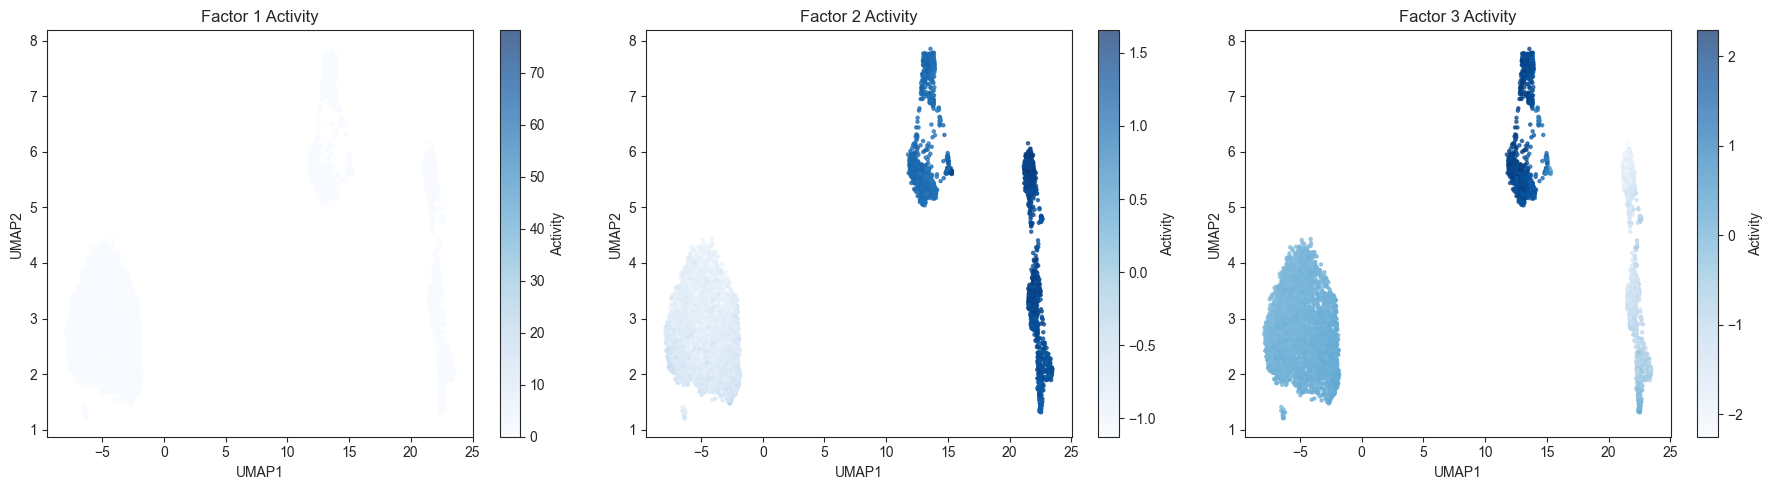

In [38]:
# Plot factor activity on UMAP (you can use the function from Task 1C)
#########################

fig, axes = plt.subplots(1,3, figsize=(18, 5))

for i in range(3):
    sc = axes[i].scatter(
        umap_coords[:, 0], umap_coords[:, 1],
        c = factor_activities[:, i],
        cmap = "Blues",
        s=5,
        alpha=0.7
    )

    axes[i].set_title(f"Factor {i+1} Activity")
    axes[i].set_xlabel("UMAP1")
    axes[i].set_ylabel("UMAP2")
    plt.colorbar(sc, ax=axes[i], label="Activity")

plt.tight_layout()
plt.show()

#########################

**Provide your text answers for Task 3A here**

Factor 1
- For the left most plot, we cant see any cluster to be highlighted, which may either indicate general biological cell activity or tecnical noise in the gene expression. 

Factor 2
- Here the left right most cluster seems to be highlighted and also the cluster in the middle. When compared to the previous UMAP plot, we can see, that this Factor2 is very similar to NKG7 and thus may describe NK-cell activity

Factor 3
- Here we can see that the middle cluster is expressed most highly, while the left most cluster is expressed a litte bit higher. This factor seems to be closest to the UMAP plot of MS4A1, which we chose as B-cell marker. Thus factor 3 may stand for B-cell activity
 

In [39]:
# Export loadings
loadings_df = pd.DataFrame(gene_loadings.T,
                           index=expression_data.columns,
                           columns=[f"factor_{i+1}" for i in range(gene_loadings.shape[0])])
loadings_df.to_csv(os.path.join(OUTPUT_PATH, "fa_gene_loadings.tsv"), sep="\t", header=True, index=True)

**You may perform GSEA with any python tool, but you can also use some online tool if you prefer that. Just make sure to submit the results.**

c:\Users\Anwender\Desktop\Uni_Tuebingen\Master\1. Semester\ML Single Cell\Assignments\Assignment03\venv\Lib\site-packages\gseapy\plot.py:756: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda _x: _x.sort_values(by=self.colname).tail(self.n_terms))
c:\Users\Anwender\Desktop\Uni_Tuebingen\Master\1. Semester\ML Single Cell\Assignments\Assignment03\venv\Lib\site-packages\gseapy\plot.py:756: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby t

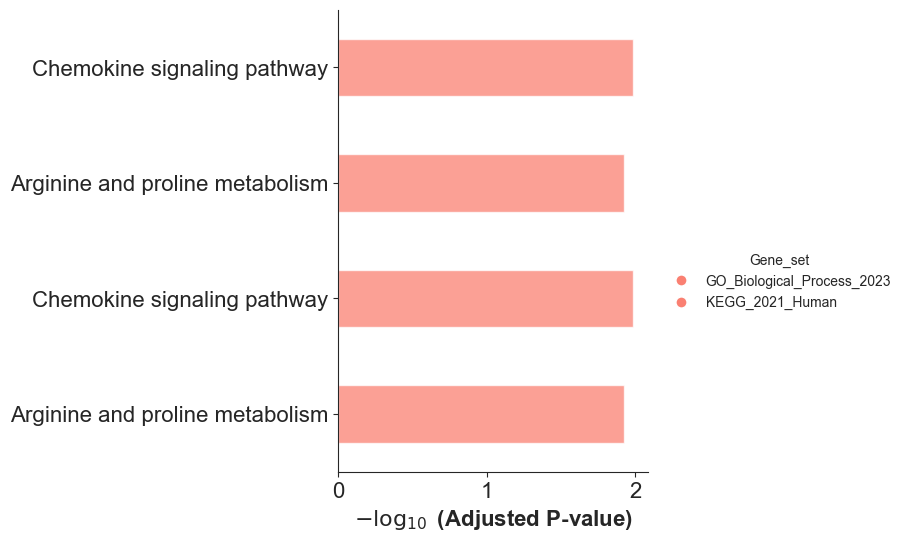

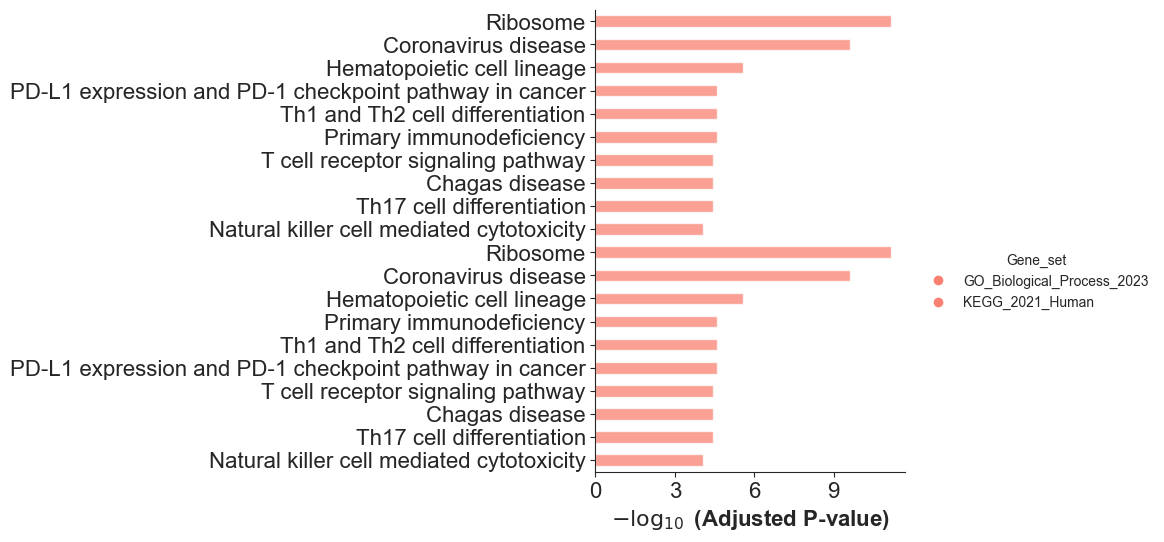

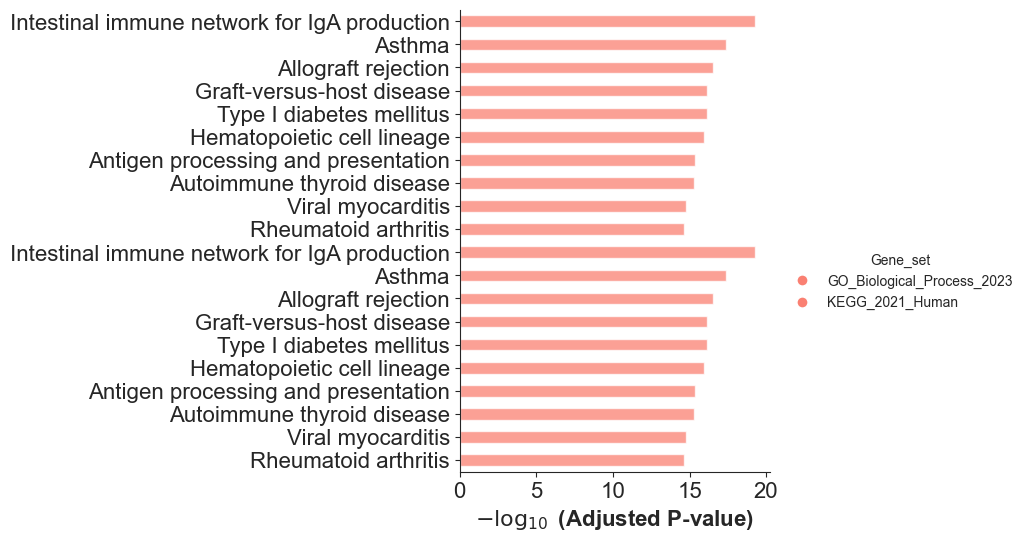

In [43]:
# Gene set enrichment analysis
#########################
gsea_results = pd.DataFrame()

for factor in loadings_df.columns: 
    top_genes = loadings_df[factor].sort_values(ascending=False).head(50).index.tolist()
    # print(f"Top genes for {factor}: {', '.join(top_genes[:10])} ...")

    enr = gp.enrichr(gene_list=top_genes,
                     gene_sets=["GO_Biological_Process_2023", "KEGG_2021_Human"],
                     organism="human",
                     cutoff=0.05)
    
    
    barplot(enr.results, column="Adjusted P-value", group="Gene_set", top_term=10, size=6)


#########################

**Provide your text answers for Task 3B here**

As we have described in subtask 3A, we identified Factor2 to be related to NK-cells, while Factor3 was associated with B-cells. For factor 1, we stated, that this seemed to be some more general biological process. 


With the GSEA (Gene Set Enrichment Analysis) tool, we now can see for Factor 1, that it could be of the Arginine and proline metabolism or a Chemokine signaling pathway. 

For Factor2 two, which were identified as NK-cells, we can see that the Ribosomes in combination with Coronavirus activity has been detecting. This maybe a signal, that the current cell might have been infected by coronavirus and has activated genes, which are relevant for coronaviruses. And because the virus replicates itself, many genes seem to be activated involving Ribosomes, which are known to be relevant for translation of rna to functional proteins. 

For Factor 3 we can see that the Intestinal immune network IgA production seems to be activated the most. As we previously had determined, that factor 3 seems to correspond to B-cells, we can now see, that those genes were activated, which are responsible for the production of antibodies against the viruses. So this indicates a immunologic response against the coronavirus has started.